# Comparación jerárquica de modelos entrenados

Este notebook carga **todos** los modelos entrenados en `artifacts/models/` (uno por
nivel de agregación M5: total, dept, store, store×dept) y compara sus predicciones
sobre el mismo período de test.

La pregunta de fondo: para un nivel de agregación dado (p.ej. el total de ventas),
¿es mejor pronosticarlo **directamente** con el modelo entrenado en ese nivel, o
**sumarlo (bottom-up)** a partir de las predicciones de un modelo entrenado en un
nivel más fino (dept, store, store×dept)? Y de paso, ¿combinar ambos enfoques
mejora el resultado?

Estructura:
1. Carga de artifacts + reconstrucción de test set + predicciones.
2. Tabla resumen de cada modelo en su propio nivel nativo.
3. Comparación al nivel **TOTAL**: modelo L1 directo vs. bottom-up desde L4/L6/L9,
   + una combinación simple (promedio) de todos.
4. Comparación a niveles intermedios: **dept** (L4 directo vs. bottom-up desde L9)
   y **store** (L6 directo vs. bottom-up desde L9).


In [11]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from loguru import logger

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

from src.data.dataset import reconstruct_test_data
from src.evaluation import build_predictions_report
from src.evaluation.point import bias, rmse, wape
from src.evaluation.scaled import compute_naive_scales


## 0. Comparativo

In [12]:
artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))
print(f"Artifacts encontrados: {[p.name for p in artifact_paths]}")

comparative = {}
for artifact_path in artifact_paths:
    artifact = joblib.load(artifact_path)
    comparative[f"{artifact['level_label']}"] = {
        "wape_test": artifact["wape_test"],
        "wrmsse_test": artifact["wrmsse_test"],
        "wape_valid": artifact["wape_valid"],
        "wrmsse_valid": artifact["wrmsse_valid"],
    }

df_comparative = pd.DataFrame(comparative).T

df_comparative

Artifacts encontrados: ['level_01_daily_total_sales_artifact.pkl', 'level_01_weekly_total_sales_artifact.pkl', 'level_02_daily_state_sales_artifact.pkl', 'level_02_weekly_state_sales_artifact.pkl', 'level_03_daily_cat_sales_artifact.pkl', 'level_03_weekly_cat_sales_artifact.pkl', 'level_04_daily_dept_sales_artifact.pkl', 'level_05_daily_state_cat_sales_artifact.pkl', 'level_05_weekly_state_cat_sales_artifact.pkl', 'level_06_daily_store_sales_artifact.pkl', 'level_06_weekly_store_sales_artifact.pkl', 'level_07_daily_state_dept_sales_artifact.pkl', 'level_07_weekly_state_dept_sales_artifact.pkl', 'level_08_daily_store_cat_sales_artifact.pkl', 'level_08_weekly_store_cat_sales_artifact.pkl', 'level_09_daily_store_dept_sales_artifact.pkl', 'level_09_weekly_store_dept_sales_artifact.pkl']


,wape_test,wrmsse_test,wape_valid,wrmsse_valid
level_01_daily,0.060689,0.600521,0.059540,0.553780
level_01_weekly,0.055487,0.408302,0.055723,0.378560
level_02_daily,0.067396,0.617709,0.078020,0.668322
level_02_weekly,0.044085,0.313295,0.061724,0.416326
level_03_daily,0.068595,0.563525,0.086169,0.785060
level_03_weekly,0.055587,0.403551,0.044501,0.319537
level_04_daily,0.076547,0.655841,0.113532,0.949031
level_05_daily,0.068488,0.574103,0.142963,1.115136
level_05_weekly,0.053420,0.367934,0.074132,0.554959
level_06_daily,0.076559,0.643302,0.090168,0.696707


In [13]:
artifact.keys()

dict_keys(['level', 'level_id', 'winner_family', 'model', 'explainer', 'model_params', 'features', 'categorical_features', 'categorical_categories', 'numerical_features', 'id_cols', 'leaky_cols', 'target', 'feature_importance', 'model_results', 'results_df', 'wape_valid', 'wrmsse_valid', 'wape_test', 'wrmsse_test', 'train_start', 'valid_start', 'test_start', 'config', 'level_label', 'mae_test', 'rmse_test', 'smape_test', 'bias_test', 'rmsle_test', 'tracking_signal_test', 'spec_test', 'mase_test'])

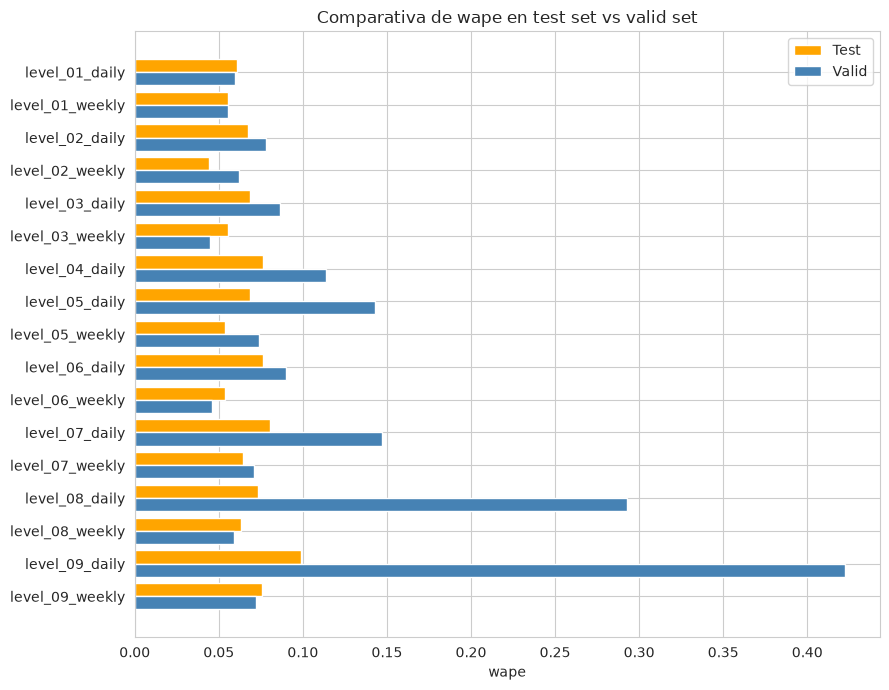

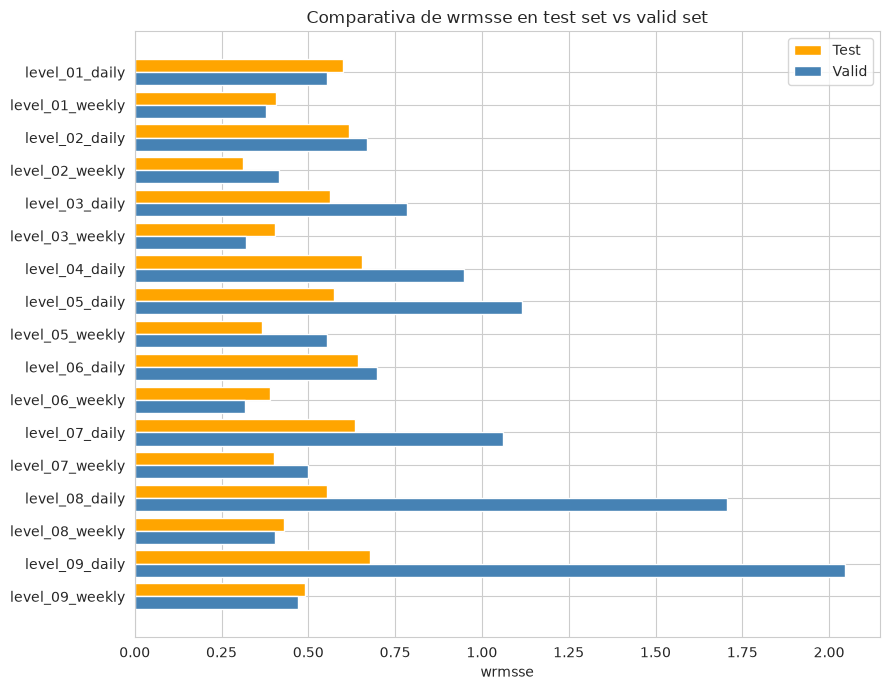

In [14]:
def plot_comparativa(df, metric, title=None, figsize=(9, 7)):
    d = df.loc[sorted(df.index, reverse=True)]
    y = range(len(d))
    height = 0.4

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh([i + height/2 for i in y], d[f"{metric}_test"], height=height, label="Test", color="orange")
    ax.barh([i - height/2 for i in y], d[f"{metric}_valid"], height=height, label="Valid", color="steelblue")

    ax.set_yticks(list(y))
    ax.set_yticklabels(d.index)
    ax.set_xlabel(metric)
    ax.set_title(title or f"Comparativa de {metric} en test set vs valid set")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_comparativa(df_comparative, "wape")
plot_comparativa(df_comparative, "wrmsse")

## 1. Carga de artifacts, reconstrucción de test y predicciones

## 1.1 Carga

In [15]:
DIMS = ["dept_id", "cat_id", "store_id", "state_id"]

def load_level(artifact_path: Path) -> dict:
    '''Carga un artifact, reconstruye su X_test/train/test y arma el detalle de
    predicciones (df_pred) con las columnas de dimension (dept_id/store_id/...)
    pegadas desde X_test, para poder reagregar a cualquier nivel mas agregado.'''
    artifact = joblib.load(artifact_path)
    model = artifact["model"]

    X_test, y_test, train, test = reconstruct_test_data(artifact)
    y_pred = model.predict(X_test)

    metrics, df_pred = build_predictions_report(
        train, test, y_test, y_pred, target_col=artifact["target"],
    )
    dims_available = [d for d in DIMS if d in X_test.columns]
    df_pred = df_pred.join(X_test[dims_available])

    return {
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "level": artifact["level"],
        "model_class": type(model).__name__,
        "n_series": df_pred["series_id"].nunique(),
        "metrics": metrics,
        "df_pred": df_pred,
        "train": train,
        "dims_available": dims_available,
    }


artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))
logger.info("Artifacts encontrados: {}", [p.name for p in artifact_paths])

LEVELS = {}
for path in artifact_paths:
    result = load_level(path)
    LEVELS[result["level_label"]] = result
    logger.info(
        "{} | {} series | modelo={} | WAPE test={:.2%} | WRMSSE test={:.3f}",
        result["level"], result["n_series"], result["model_class"],
        result["metrics"]["wape"], result["metrics"]["wrmsse"],
    )


2026-09-11 21:18:38.256 | INFO     | __main__:<module>:33 - Artifacts encontrados: ['level_01_daily_total_sales_artifact.pkl', 'level_01_weekly_total_sales_artifact.pkl', 'level_02_daily_state_sales_artifact.pkl', 'level_02_weekly_state_sales_artifact.pkl', 'level_03_daily_cat_sales_artifact.pkl', 'level_03_weekly_cat_sales_artifact.pkl', 'level_04_daily_dept_sales_artifact.pkl', 'level_05_daily_state_cat_sales_artifact.pkl', 'level_05_weekly_state_cat_sales_artifact.pkl', 'level_06_daily_store_sales_artifact.pkl', 'level_06_weekly_store_sales_artifact.pkl', 'level_07_daily_state_dept_sales_artifact.pkl', 'level_07_weekly_state_dept_sales_artifact.pkl', 'level_08_daily_store_cat_sales_artifact.pkl', 'level_08_weekly_store_cat_sales_artifact.pkl', 'level_09_daily_store_dept_sales_artifact.pkl', 'level_09_weekly_store_dept_sales_artifact.pkl']


2026-09-11 21:18:39.354 | INFO     | src.data.dataset:load_data:58 - level_01_daily_total | target=sales | 1,941 filas | 191 features (9 categóricas)
2026-09-11 21:18:39.383 | INFO     | src.data.temporal_split:log_summary:41 - Train : 2011-01-29 to 2015-04-26 (1,549 days, 1,549 rows)
2026-09-11 21:18:39.385 | INFO     | src.data.temporal_split:log_summary:42 - Valid : 2015-04-27 to 2016-04-24 (364 days, 364 rows)
2026-09-11 21:18:39.387 | INFO     | src.data.temporal_split:log_summary:43 - Test  : 2016-04-25 to 2016-05-22 (28 days, 28 rows)
2026-09-11 21:18:39.731 | INFO     | src.data.dataset:split_data:119 - Features: 131 (1 categóricas)
2026-09-11 21:18:39.885 | INFO     | __main__:<module>:39 - level_01_daily_total | 1 series | modelo=FittedModel | WAPE test=6.07% | WRMSSE test=0.601
2026-09-11 21:18:40.289 | INFO     | src.data.dataset:load_data:58 - level_01_weekly_total | target=sales | 278 filas | 109 features (9 categóricas)
2026-09-11 21:18:40.300 | INFO     | src.data.tempo

## 2. Resumen de cada modelo en su propio nivel nativo

In [16]:
summary_rows = []
for level_id, res in sorted(LEVELS.items()):
    m = res["metrics"]
    summary_rows.append({
        "level_label": res["level_label"],
        "level": res["level"],
        "n_series": res["n_series"],
        "modelo": res["model_class"],
        "wape": m["wape"],
        "wrmsse": m["wrmsse"],
        "bias": m["bias"],
        "rmse": m["rmse"],
    })

df_summary = pd.DataFrame(summary_rows).set_index("level_label")
df_summary.style.format({"wape": "{:.2%}", "wrmsse": "{:.3f}", "bias": "{:.2%}", "rmse": "{:,.1f}"})


,level,n_series,modelo,wape,wrmsse,bias,rmse
level_label,,,,,,,
level_01_daily,level_01_daily_total,1,FittedModel,6.07%,0.601,-5.95%,"3,435.9"
level_01_weekly,level_01_weekly_total,1,FittedModel,5.55%,0.408,-5.55%,"19,575.3"
level_02_daily,level_02_daily_state,3,FittedModel,6.74%,0.618,-6.19%,"1,314.6"
level_02_weekly,level_02_weekly_state,3,FittedModel,4.41%,0.313,-3.95%,"5,274.9"
level_03_daily,level_03_daily_cat,3,FittedModel,6.86%,0.564,-6.45%,"1,705.2"
level_03_weekly,level_03_weekly_cat,3,FittedModel,5.56%,0.404,-3.53%,"9,105.9"
level_04_daily,level_04_daily_dept,7,FittedModel,7.65%,0.656,-6.16%,839.9
level_05_daily,level_05_daily_state_cat,9,FittedModel,6.85%,0.574,-5.34%,582.1
level_05_weekly,level_05_weekly_state_cat,9,FittedModel,5.34%,0.368,-5.21%,"2,962.6"


## 3. Comparación al nivel TOTAL

Se agregan (`groupby("date").sum()`) las predicciones de cada nivel a la serie
diaria total y se comparan contra el mismo real (`sales`), que por construcción es
idéntico en todos los niveles. También se arma una combinación simple: el
promedio de las 4 predicciones totales, como primer paso hacia una reconciliación
jerárquica más formal (bottom-up ya está acá; top-down por proporciones históricas
o MinT/optimal reconciliation -- p.ej. con `hierarchicalforecast` -- quedan como
extensión natural).

In [17]:
def aggregate_to_total(df_pred: pd.DataFrame) -> pd.DataFrame:
    agg = df_pred.groupby("date").agg(actual=("sales", "sum"), y_pred=("y_pred", "sum"))
    return agg


def to_weekly(agg: pd.DataFrame) -> pd.DataFrame:
    """Reagrega una serie diaria a semanal (lunes-domingo, fecha = lunes de esa
    semana, igual que el date_trunc('week', ...) usado al construir los datasets
    weekly -- ver src/data/base_query.py) para que sea comparable con L1, que
    solo tiene artifact weekly."""
    week_start = agg.index - pd.to_timedelta(agg.index.dayofweek, unit="D")
    return agg.groupby(week_start).sum()


# Solo se agregan al total los niveles que particionan por completo la serie total
# (item/item_store, 10-12, están filtrados a un subconjunto dept/store y no sumarían al total real).
VALID_LEVELS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# LEVELS está keyeado por level_label ("level_04_daily", "level_04_weekly", ...),
# no por level_id: varios niveles (3, 5-9) tienen artifacts en ambos grains -- nos
# quedamos con el nativo daily de cada nivel (más fino) y sólo caemos a weekly
# cuando no hay daily entrenado (caso de L1 hoy).
GRAIN_PRIORITY = {"daily": 0, "weekly": 1}

def grain_of(res: dict) -> str:
    return res["level_label"].rsplit("_", 1)[-1]

levels_by_id: dict[int, dict] = {}
for res in LEVELS.values():
    level_id = res["level_id"]
    current = levels_by_id.get(level_id)
    if current is None or GRAIN_PRIORITY[grain_of(res)] < GRAIN_PRIORITY[grain_of(current)]:
        levels_by_id[level_id] = res

# L1 solo existe en weekly: todo se reagrega a semanal (lunes de cada semana)
# para poder comparar contra L1 en la misma base -- sumar los diarios a nivel de
# semana no pierde nada (es la misma cuenta agregada distinto), pero unirlos sin
# reagregar sí: las fechas diarias y semanales no calzan al pegar columnas por
# índice (cada fecha semanal solo matchea el día puntual, no la semana entera).
total_aggs = {
    level_id: to_weekly(aggregate_to_total(res["df_pred"])) if grain_of(res) == "daily"
    else aggregate_to_total(res["df_pred"])
    for level_id, res in levels_by_id.items()
    if level_id in VALID_LEVELS
}

df_total = pd.DataFrame({"actual": next(iter(total_aggs.values()))["actual"]})
for level_id, agg in sorted(total_aggs.items()):
    df_total[f"L{level_id}"] = agg["y_pred"]

# combinación naive: promedio de las predicciones de todos los niveles disponibles
pred_cols = [c for c in df_total.columns if c != "actual"]
#df_total["Promedio de niveles"] = df_total[pred_cols].mean(axis=1)

df_total.round(0).head()

,actual,L1,L2,L3,L4,L5,L6,L7,L8,L9
date,,,,,,,,,,
2016-04-25,289814.0,280923.0,279157.0,280339.0,283668.0,282057.0,278886.0,283755.0,283554.0,283902.0
2016-05-02,311512.0,295087.0,294782.0,294894.0,297023.0,299349.0,297018.0,302252.0,302423.0,303342.0
2016-05-09,326832.0,300277.0,297683.0,295569.0,293792.0,299030.0,297876.0,298806.0,305336.0,300217.0
2016-05-16,303606.0,282171.0,283858.0,281563.0,281429.0,285503.0,281813.0,284786.0,292035.0,286219.0


In [18]:
# Escala WRMSSE del total: MSE del naive de 1 día in-sample sobre el train del
# nivel L1 (la serie total ya es una sola serie -- no hay ponderación entre grupos).
train_total = levels_by_id[1]["train"][["date", "sales"]].copy()
train_total["series_id"] = "TOTAL"
scale_total = compute_naive_scales(train_total, group_col="series_id", target_col="sales")["TOTAL"]

rows = []
for col in [c for c in df_total.columns if c != "actual"]:
    y_true, y_pred = df_total["actual"], df_total[col]
    rows.append({
        "enfoque": col,
        "wape": wape(y_true, y_pred),
        "bias": bias(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "wrmsse": rmse(y_true, y_pred) / np.sqrt(scale_total),
    })

df_total_metrics = pd.DataFrame(rows).sort_values("wape").reset_index(drop=True)
df_total_metrics

,enfoque,wape,bias,rmse,wrmsse
0,L8,0.039306,-0.039306,13395.555028,2.341287
1,L9,0.047155,-0.047155,16676.080460,2.914660
2,L7,0.050468,-0.050468,17763.080793,3.104647
3,L5,0.053440,-0.053440,18088.528347,3.161529
4,L1,0.059513,-0.059513,19451.592197,3.399767
5,L4,0.061580,-0.061580,21396.059018,3.739622
6,L6,0.061839,-0.061839,20266.240432,3.542151
7,L2,0.061931,-0.061931,20205.891802,3.531604
8,L3,0.064460,-0.064460,21384.588884,3.737617


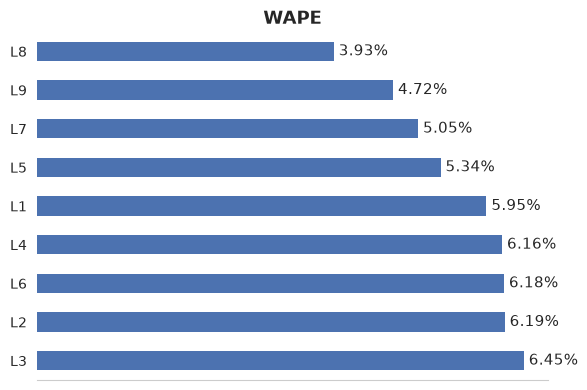

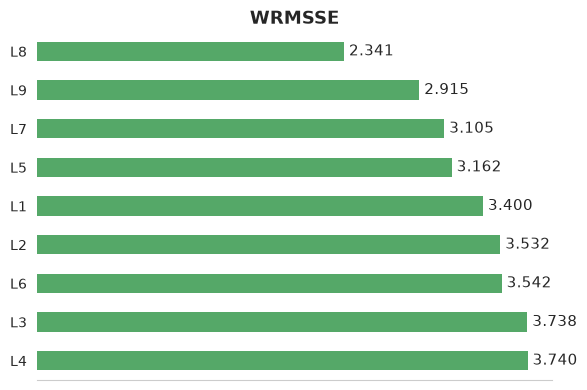

In [19]:
import matplotlib.pyplot as plt

df_plot = df_total_metrics.set_index("enfoque")

metrics = {"wape": ("WAPE", "%"), "wrmsse": ("WRMSSE", "num")}
colors = {"wape": "#4C72B0", "bias": "#DD8452", "wrmsse": "#55A868"}

for metric, (title, fmt_type) in metrics.items():
    sort_type = False if metric in ["wape", "wrmsse"] else False
    data = df_plot[metric].sort_values(ascending=sort_type)

    fig, ax = plt.subplots(figsize=(6, 4))
    data.plot(kind="barh", ax=ax, color=colors[metric], edgecolor="none")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(left=False)
    ax.set_xticks([])

    for i, v in enumerate(data):
        label = f"{v:.2%}" if fmt_type == "%" else f"{v:.3f}"
        ax.text(v, i, f" {label}", va="center", fontsize=11)

    plt.tight_layout()
    plt.grid(False)
    plt.show()

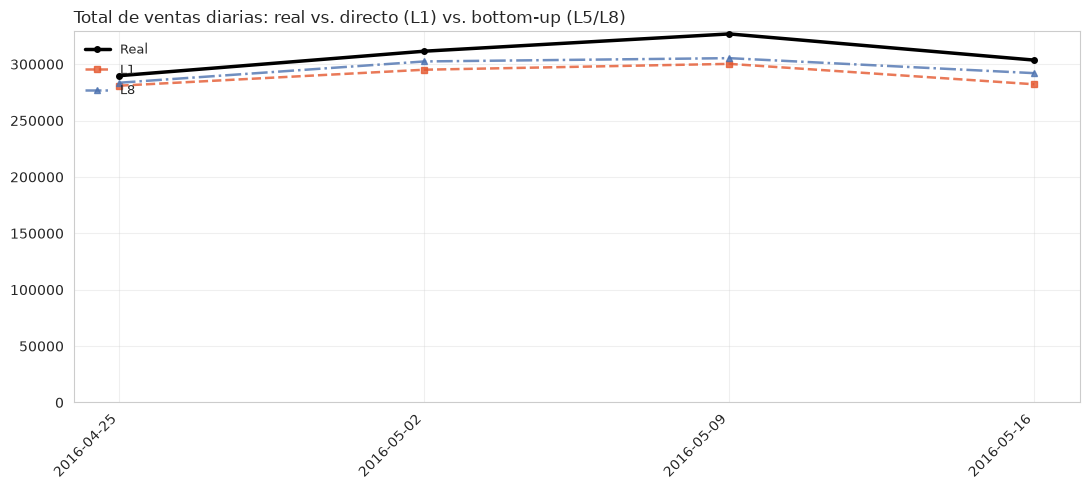

In [20]:
df_plot = df_total[['actual', 'L1', 'L8']].copy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df_plot.index, df_plot["actual"], label="Real", color="black",
        linewidth=2.5, marker="o", markersize=4, zorder=3)

styles = [
    {"color": "#E4572E", "linestyle": "--", "marker": "s"},
    {"color": "#4C72B0", "linestyle": "-.", "marker": "^"},
    {"color": "#55A868", "linestyle": ":", "marker": "D"},
]

for col, style in zip([c for c in df_plot.columns if c != "actual"], styles):
    ax.plot(df_plot.index, df_plot[col], label=col, alpha=0.8,
            linewidth=1.8, markersize=4, zorder=2, **style)

ax.set_title("Total de ventas diarias: real vs. directo (L1) vs. bottom-up (L5/L8)", loc="left")
ax.set_xlabel("")
ax.set_xticks(df_plot.index)
ax.legend(loc="upper left", fontsize=9, frameon=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.ylim(0)
plt.show()

## Conclusiones rápidas

- Revisar `df_total_metrics`: si "Promedio de niveles" queda por debajo del mejor
  enfoque individual, hay señal de que combinar información de distintos niveles
  de agregación reduce error -- la motivación estándar detrás de la reconciliación
  jerárquica (bottom-up, top-down, MinT).
- `df_dept_compare` / `df_store_compare` (columna `gana_bottomup`) muestran, serie
  por serie, si conviene más el modelo especializado en ese nivel o la suma desde
  el nivel más fino -- normalmente depende de cuánta señal específica del grupo
  (dept/store) exista vs. cuánta información se gana de tener series individuales
  más finas para el modelo de L9.
- Extensión natural: formalizar esto con reconciliación óptima (p.ej.
  `hierarchicalforecast` de Nixtla, que ya cubre bottom-up/top-down/MinT sobre esta
  misma estructura de niveles).
